# 💧 AquaVision — Water Quality Index Analysis & Prediction
### Final Year Project | Machine Learning + Environmental Data Science
---

## 📦 CELL 1 — Install & Import Libraries

In [4]:
# Run this cell first to install all dependencies
import subprocess, sys
packages = [
    'pandas', 'numpy', 'matplotlib', 'seaborn', 'scikit-learn',
    'xgboost', 'lightgbm', 'scipy', 'plotly', 'pymannkendall',
    'imbalanced-learn', 'shap', 'joblib'
]
for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
print('✅ All packages installed successfully!')

✅ All packages installed successfully!


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import (mean_squared_error, r2_score, mean_absolute_error,
                              classification_report, confusion_matrix, accuracy_score)
from sklearn.impute import KNNImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy import stats
from scipy.stats import normaltest, shapiro
import xgboost as xgb
import lightgbm as lgb
import shap
import joblib
import os

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Blues_d')
BLUE   = '#1565C0'
TEAL   = '#00897B'
LIGHT  = '#E3F2FD'
WARN   = '#FF6F00'
DANGER = '#B71C1C'

print('✅ Libraries loaded!')

✅ Libraries loaded!


---
## 📂 WEEK 1 — Data Collection, Cleaning & EDA

### TASK 1-1 · Load Dataset & Exploratory Data Analysis

In [7]:
# ── Load Data ──────────────────────────────────────────────────────────────
df_raw = pd.read_csv('water_dataX.csv', encoding='latin1')

# Rename columns for clarity
df_raw.columns = [
    'station_code', 'location', 'state', 'temp',
    'do', 'ph', 'conductivity', 'bod',
    'nitrate', 'fecal_coliform', 'total_coliform', 'year'
]

print('='*55)
print(f'  💧 AquaVision — Dataset Overview')
print('='*55)
print(f'  Rows       : {df_raw.shape[0]:,}')
print(f'  Columns    : {df_raw.shape[1]}')
print(f'  Year range : {df_raw.year.min()} – {df_raw.year.max()}')
print(f'  States     : {df_raw.state.nunique()}')
print(f'  Stations   : {df_raw.station_code.nunique()}')
print('='*55)
df_raw.head()

  💧 AquaVision — Dataset Overview
  Rows       : 1,991
  Columns    : 12
  Year range : 2003 – 2014
  States     : 203
  Stations   : 321


,station_code,location,state,temp,do,ph,conductivity,bod,nitrate,fecal_coliform,total_coliform,year
0,1393,"DAMANGANGA AT D/S OF MADHUBAN, DAMAN",DAMAN & DIU,30.6,6.7,7.5,203,NAN,0.1,11,27,2014
1,1399,ZUARI AT D/S OF PT. WHERE KUMBARJRIA CANAL JOI...,GOA,29.8,5.7,7.2,189,2,0.2,4953,8391,2014
2,1475,ZUARI AT PANCHAWADI,GOA,29.5,6.3,6.9,179,1.7,0.1,3243,5330,2014
3,3181,RIVER ZUARI AT BORIM BRIDGE,GOA,29.7,5.8,6.9,64,3.8,0.5,5382,8443,2014
4,3182,RIVER ZUARI AT MARCAIM JETTY,GOA,29.5,5.8,7.3,83,1.9,0.4,3428,5500,2014


In [8]:
# Convert numeric columns
num_cols = ['temp', 'do', 'ph', 'conductivity', 'bod', 'nitrate', 'fecal_coliform', 'total_coliform']
for col in num_cols:
    df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')

print('📊 Descriptive Statistics:')
df_raw[num_cols].describe().round(3)

📊 Descriptive Statistics:


,temp,do,ph,conductivity,bod,nitrate,fecal_coliform,total_coliform
count,1899.000,1960.000,1983.000,1966.000,1948.000,1766.000,1.675000e+03,1.859000e+03
mean,26.210,6.393,112.091,1786.466,6.940,1.623,3.625294e+05,5.336872e+05
std,3.366,1.333,1878.931,5552.276,29.400,4.090,8.764767e+06,1.423428e+07
min,10.000,0.000,0.000,0.400,0.100,0.000,0.000000e+00,0.000000e+00
25%,24.750,5.900,6.900,78.000,1.200,0.240,2.600000e+01,1.060000e+02
50%,27.000,6.700,7.300,183.000,1.896,0.516,2.210000e+02,4.680000e+02
75%,28.400,7.200,7.700,592.750,3.600,1.500,9.965000e+02,1.919000e+03
max,35.000,11.400,67115.000,65700.000,534.500,108.700,2.725216e+08,5.110909e+08


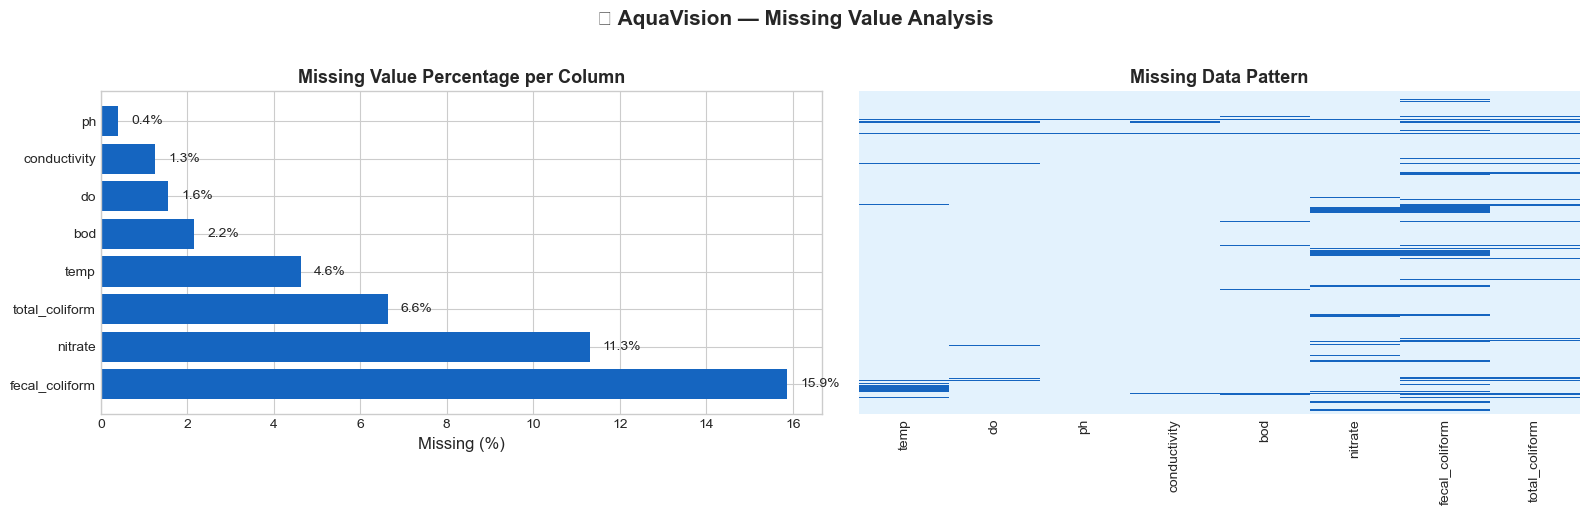

In [9]:
# Missing value heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

missing_pct = (df_raw.isnull().sum() / len(df_raw) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

axes[0].barh(missing_pct.index, missing_pct.values, color=BLUE)
axes[0].set_xlabel('Missing (%)', fontsize=12)
axes[0].set_title('Missing Value Percentage per Column', fontsize=13, fontweight='bold')
for i, v in enumerate(missing_pct.values):
    axes[0].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=10)

sns.heatmap(df_raw[num_cols].isnull(), ax=axes[1], cbar=False,
            cmap=['#E3F2FD', BLUE], yticklabels=False)
axes[1].set_title('Missing Data Pattern', fontsize=13, fontweight='bold')

plt.suptitle('💧 AquaVision — Missing Value Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### TASK 1-2 · KNN Imputation & Data Cleaning

In [10]:
# KNN Imputation
imputer = KNNImputer(n_neighbors=5)
df_imputed = df_raw.copy()
df_imputed[num_cols] = imputer.fit_transform(df_raw[num_cols])

print(f'Before imputation — nulls: {df_raw[num_cols].isnull().sum().sum()}')
print(f'After  imputation — nulls: {df_imputed[num_cols].isnull().sum().sum()}')
print('✅ KNN Imputation complete!')

Before imputation — nulls: 872
After  imputation — nulls: 0
✅ KNN Imputation complete!


### TASK 1-3 · Water Quality Index (WQI) Calculation

In [11]:
# ── WQI Calculation (CPCB / NFS method) ────────────────────────────────────
# Ideal and permissible values (WHO/IS standards)
standards = {
    'do'          : {'ideal': 14.6, 'permissible': 5.0,  'weight': 0.31},
    'ph'          : {'ideal': 7.0,  'permissible': 8.5,  'weight': 0.22},
    'bod'         : {'ideal': 0.0,  'permissible': 3.0,  'weight': 0.19},
    'nitrate'     : {'ideal': 0.0,  'permissible': 45.0, 'weight': 0.10},
    'conductivity': {'ideal': 0.0,  'permissible': 500.0,'weight': 0.08},
    'temp'        : {'ideal': 25.0, 'permissible': 30.0, 'weight': 0.10},
}

df = df_imputed.copy()

# Sub-index for each parameter
wqi_total = np.zeros(len(df))
weight_sum = sum(v['weight'] for v in standards.values())

for param, vals in standards.items():
    qi = ((df[param] - vals['ideal']) / (vals['permissible'] - vals['ideal'])) * 100
    qi = qi.clip(lower=0)
    wqi_total += vals['weight'] * qi

df['WQI'] = (wqi_total / weight_sum).round(2)

# WQI Category
def wqi_category(score):
    if score < 25:   return 'Excellent'
    elif score < 50: return 'Good'
    elif score < 75: return 'Poor'
    elif score < 100: return 'Very Poor'
    else:            return 'Unfit for Drinking'

df['WQI_Category'] = df['WQI'].apply(wqi_category)

print('WQI Distribution:')
print(df['WQI_Category'].value_counts())
print(f'\nWQI Stats  →  Mean: {df.WQI.mean():.2f}  |  Std: {df.WQI.std():.2f}  |  Max: {df.WQI.max():.2f}')

WQI Distribution:
WQI_Category
Good                  791
Unfit for Drinking    535
Poor                  535
Very Poor             128
Excellent               2
Name: count, dtype: int64

WQI Stats  →  Mean: 1646.58  |  Std: 27508.76  |  Max: 984314.91


### TASK 1-4 · Outlier Detection & Removal

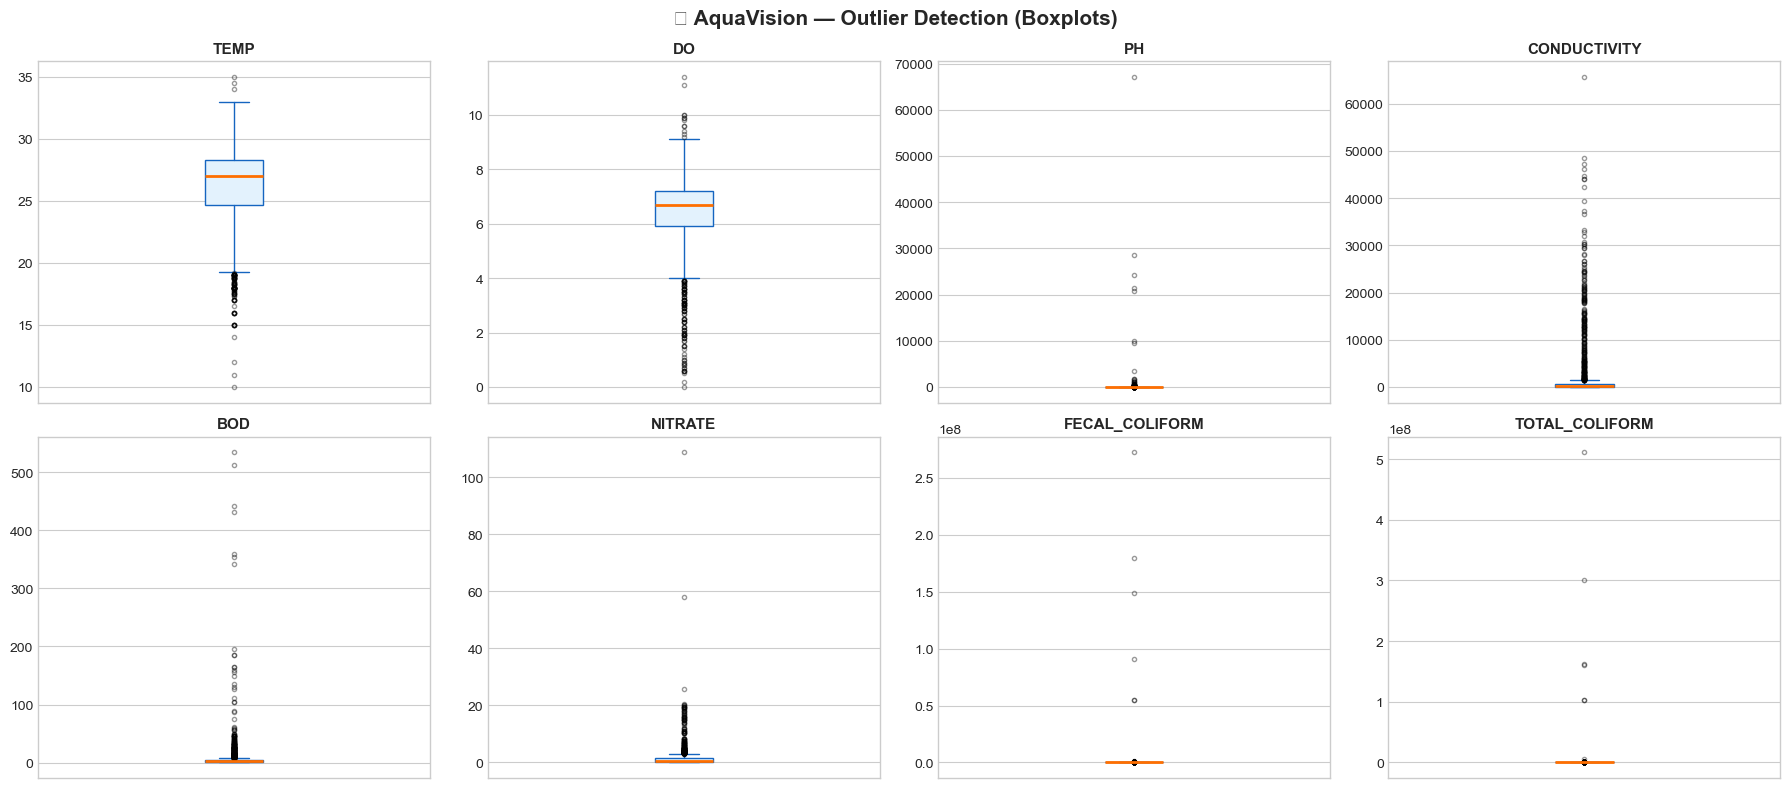

Rows before outlier removal: 1,991
Rows after  outlier removal: 1,731
Removed: 260 rows


In [12]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor=LIGHT, color=BLUE),
                    medianprops=dict(color=WARN, linewidth=2),
                    whiskerprops=dict(color=BLUE),
                    capprops=dict(color=BLUE),
                    flierprops=dict(marker='o', color=DANGER, alpha=0.4, markersize=3))
    axes[i].set_title(col.upper(), fontsize=11, fontweight='bold')
    axes[i].set_xticks([])

plt.suptitle('💧 AquaVision — Outlier Detection (Boxplots)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# IQR Removal
df_clean = df.copy()
before = len(df_clean)
for col in num_cols:
    Q1 = df_clean[col].quantile(0.01)
    Q3 = df_clean[col].quantile(0.99)
    df_clean = df_clean[(df_clean[col] >= Q1) & (df_clean[col] <= Q3)]
print(f'Rows before outlier removal: {before:,}')
print(f'Rows after  outlier removal: {len(df_clean):,}')
print(f'Removed: {before - len(df_clean):,} rows')

### TASK 1-5 · Skewness & Distribution Analysis

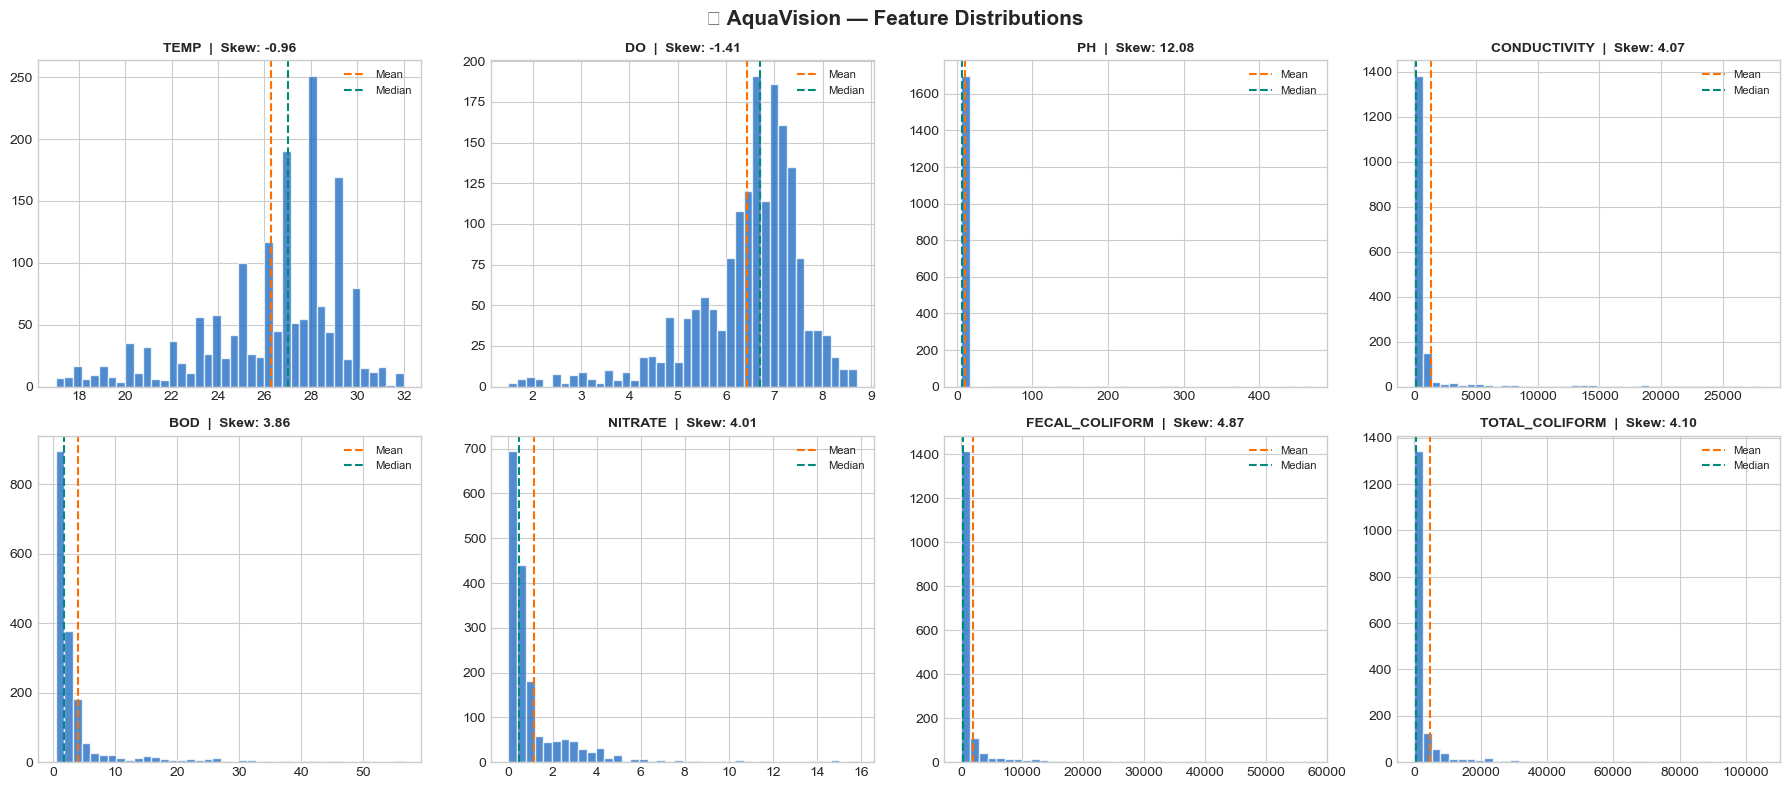

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df_clean[col], bins=40, color=BLUE, alpha=0.75, edgecolor='white')
    axes[i].axvline(df_clean[col].mean(), color=WARN, linestyle='--', linewidth=1.5, label='Mean')
    axes[i].axvline(df_clean[col].median(), color=TEAL, linestyle='--', linewidth=1.5, label='Median')
    axes[i].set_title(f'{col.upper()}  |  Skew: {df_clean[col].skew():.2f}', fontsize=10, fontweight='bold')
    axes[i].legend(fontsize=8)

plt.suptitle('💧 AquaVision — Feature Distributions', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 📊 WEEK 1 — Advanced Visualization

### Correlation Heatmap

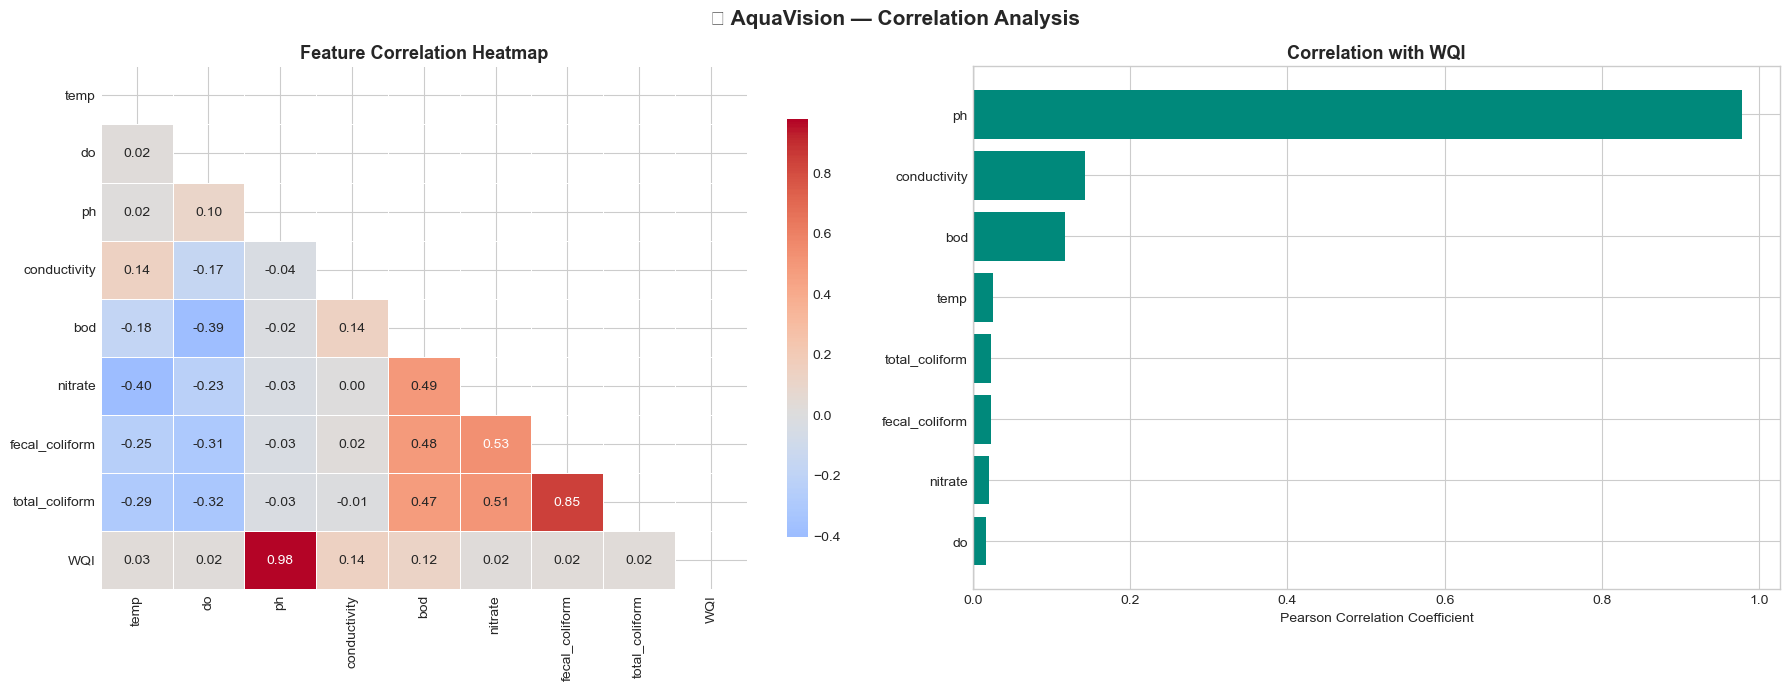

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

corr = df_clean[num_cols + ['WQI']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=axes[0], annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
axes[0].set_title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')

# WQI vs each parameter scatter
wqi_corr = corr['WQI'].drop('WQI').sort_values()
colors = [DANGER if x < 0 else TEAL for x in wqi_corr.values]
axes[1].barh(wqi_corr.index, wqi_corr.values, color=colors)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Correlation with WQI', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Pearson Correlation Coefficient')

plt.suptitle('💧 AquaVision — Correlation Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### WQI Category Distribution & State-wise Analysis

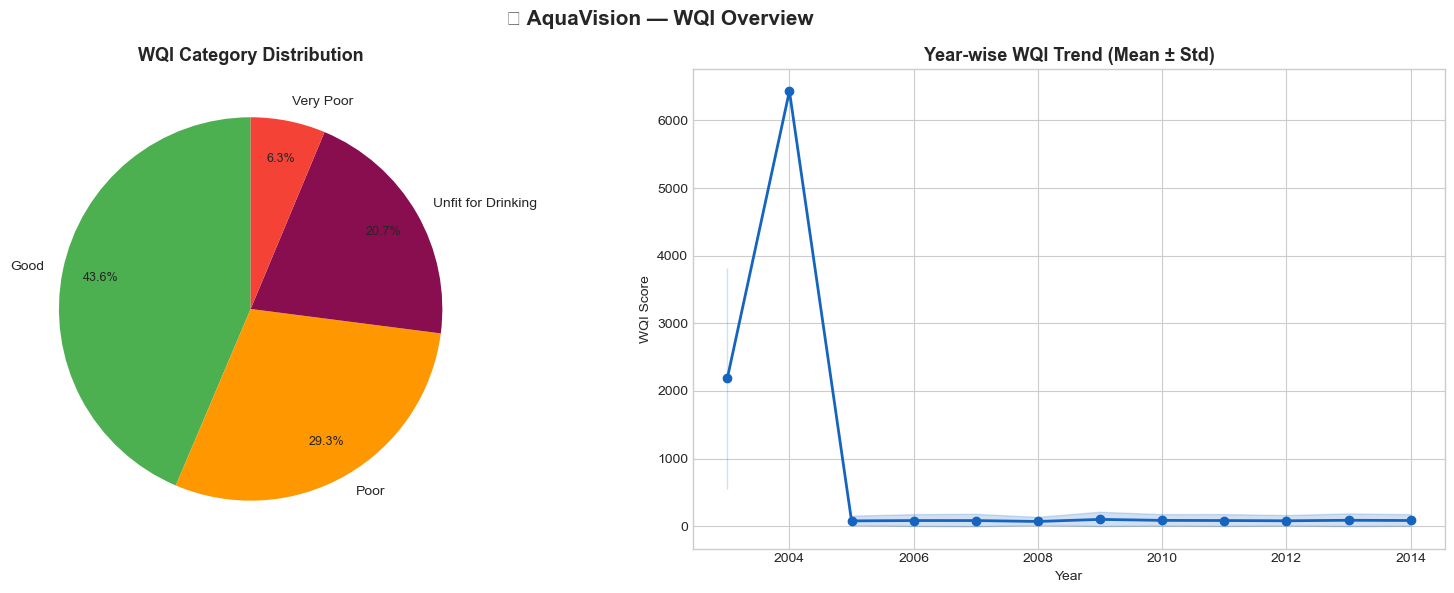

In [15]:
cat_colors = {
    'Excellent': '#1B5E20', 'Good': '#4CAF50',
    'Poor': '#FF9800', 'Very Poor': '#F44336', 'Unfit for Drinking': '#880E4F'
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cat_counts = df_clean['WQI_Category'].value_counts()
colors = [cat_colors.get(c, BLUE) for c in cat_counts.index]
wedges, texts, autotexts = axes[0].pie(
    cat_counts.values, labels=cat_counts.index, autopct='%1.1f%%',
    colors=colors, startangle=90, pctdistance=0.8
)
for t in autotexts: t.set_fontsize(9)
axes[0].set_title('WQI Category Distribution', fontsize=13, fontweight='bold')

# Year-wise WQI trend
yearly = df_clean.groupby('year')['WQI'].agg(['mean','std']).reset_index()
axes[1].fill_between(yearly.year, yearly['mean']-yearly['std'], yearly['mean']+yearly['std'],
                     alpha=0.2, color=BLUE)
axes[1].plot(yearly.year, yearly['mean'], '-o', color=BLUE, linewidth=2, markersize=6)
axes[1].set_title('Year-wise WQI Trend (Mean ± Std)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Year'); axes[1].set_ylabel('WQI Score')

plt.suptitle('💧 AquaVision — WQI Overview', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

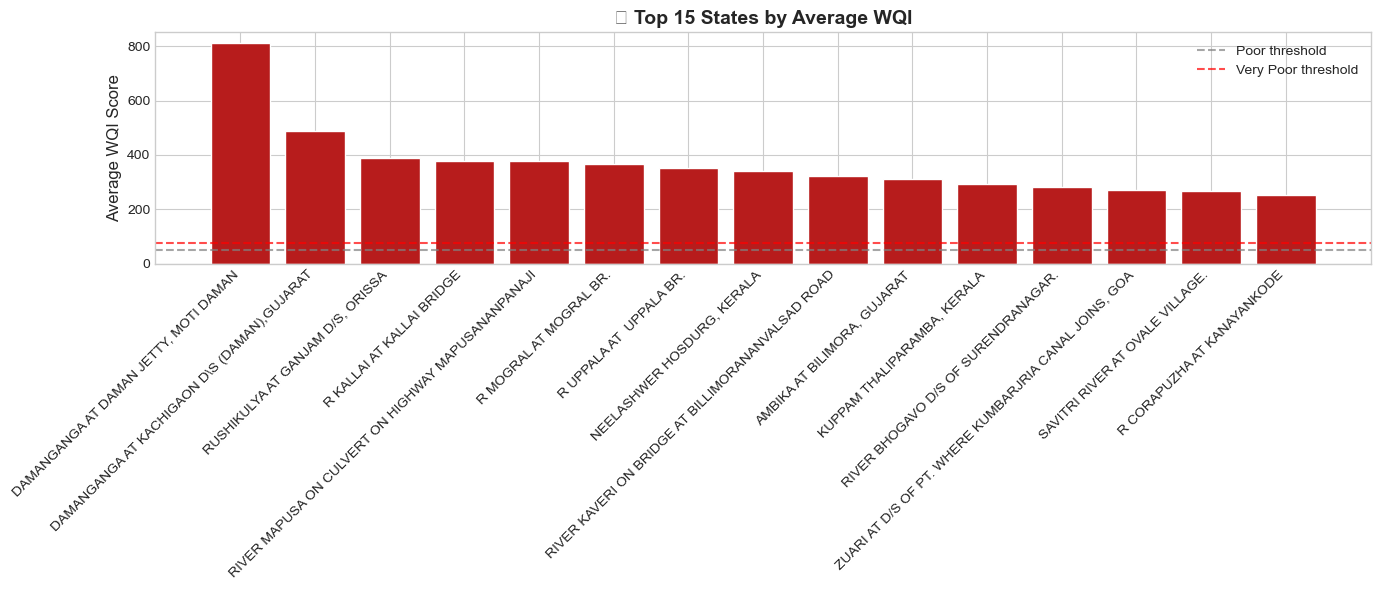

In [16]:
# Top 15 states by average WQI
state_wqi = df_clean.groupby('state')['WQI'].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(14, 6))
bars = plt.bar(state_wqi.index, state_wqi.values,
               color=[DANGER if v > 75 else WARN if v > 50 else TEAL for v in state_wqi.values],
               edgecolor='white')
plt.axhline(50, color='gray', linestyle='--', alpha=0.7, label='Poor threshold')
plt.axhline(75, color='red',  linestyle='--', alpha=0.7, label='Very Poor threshold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.ylabel('Average WQI Score', fontsize=12)
plt.title('💧 Top 15 States by Average WQI', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

### Pairplot & PCA

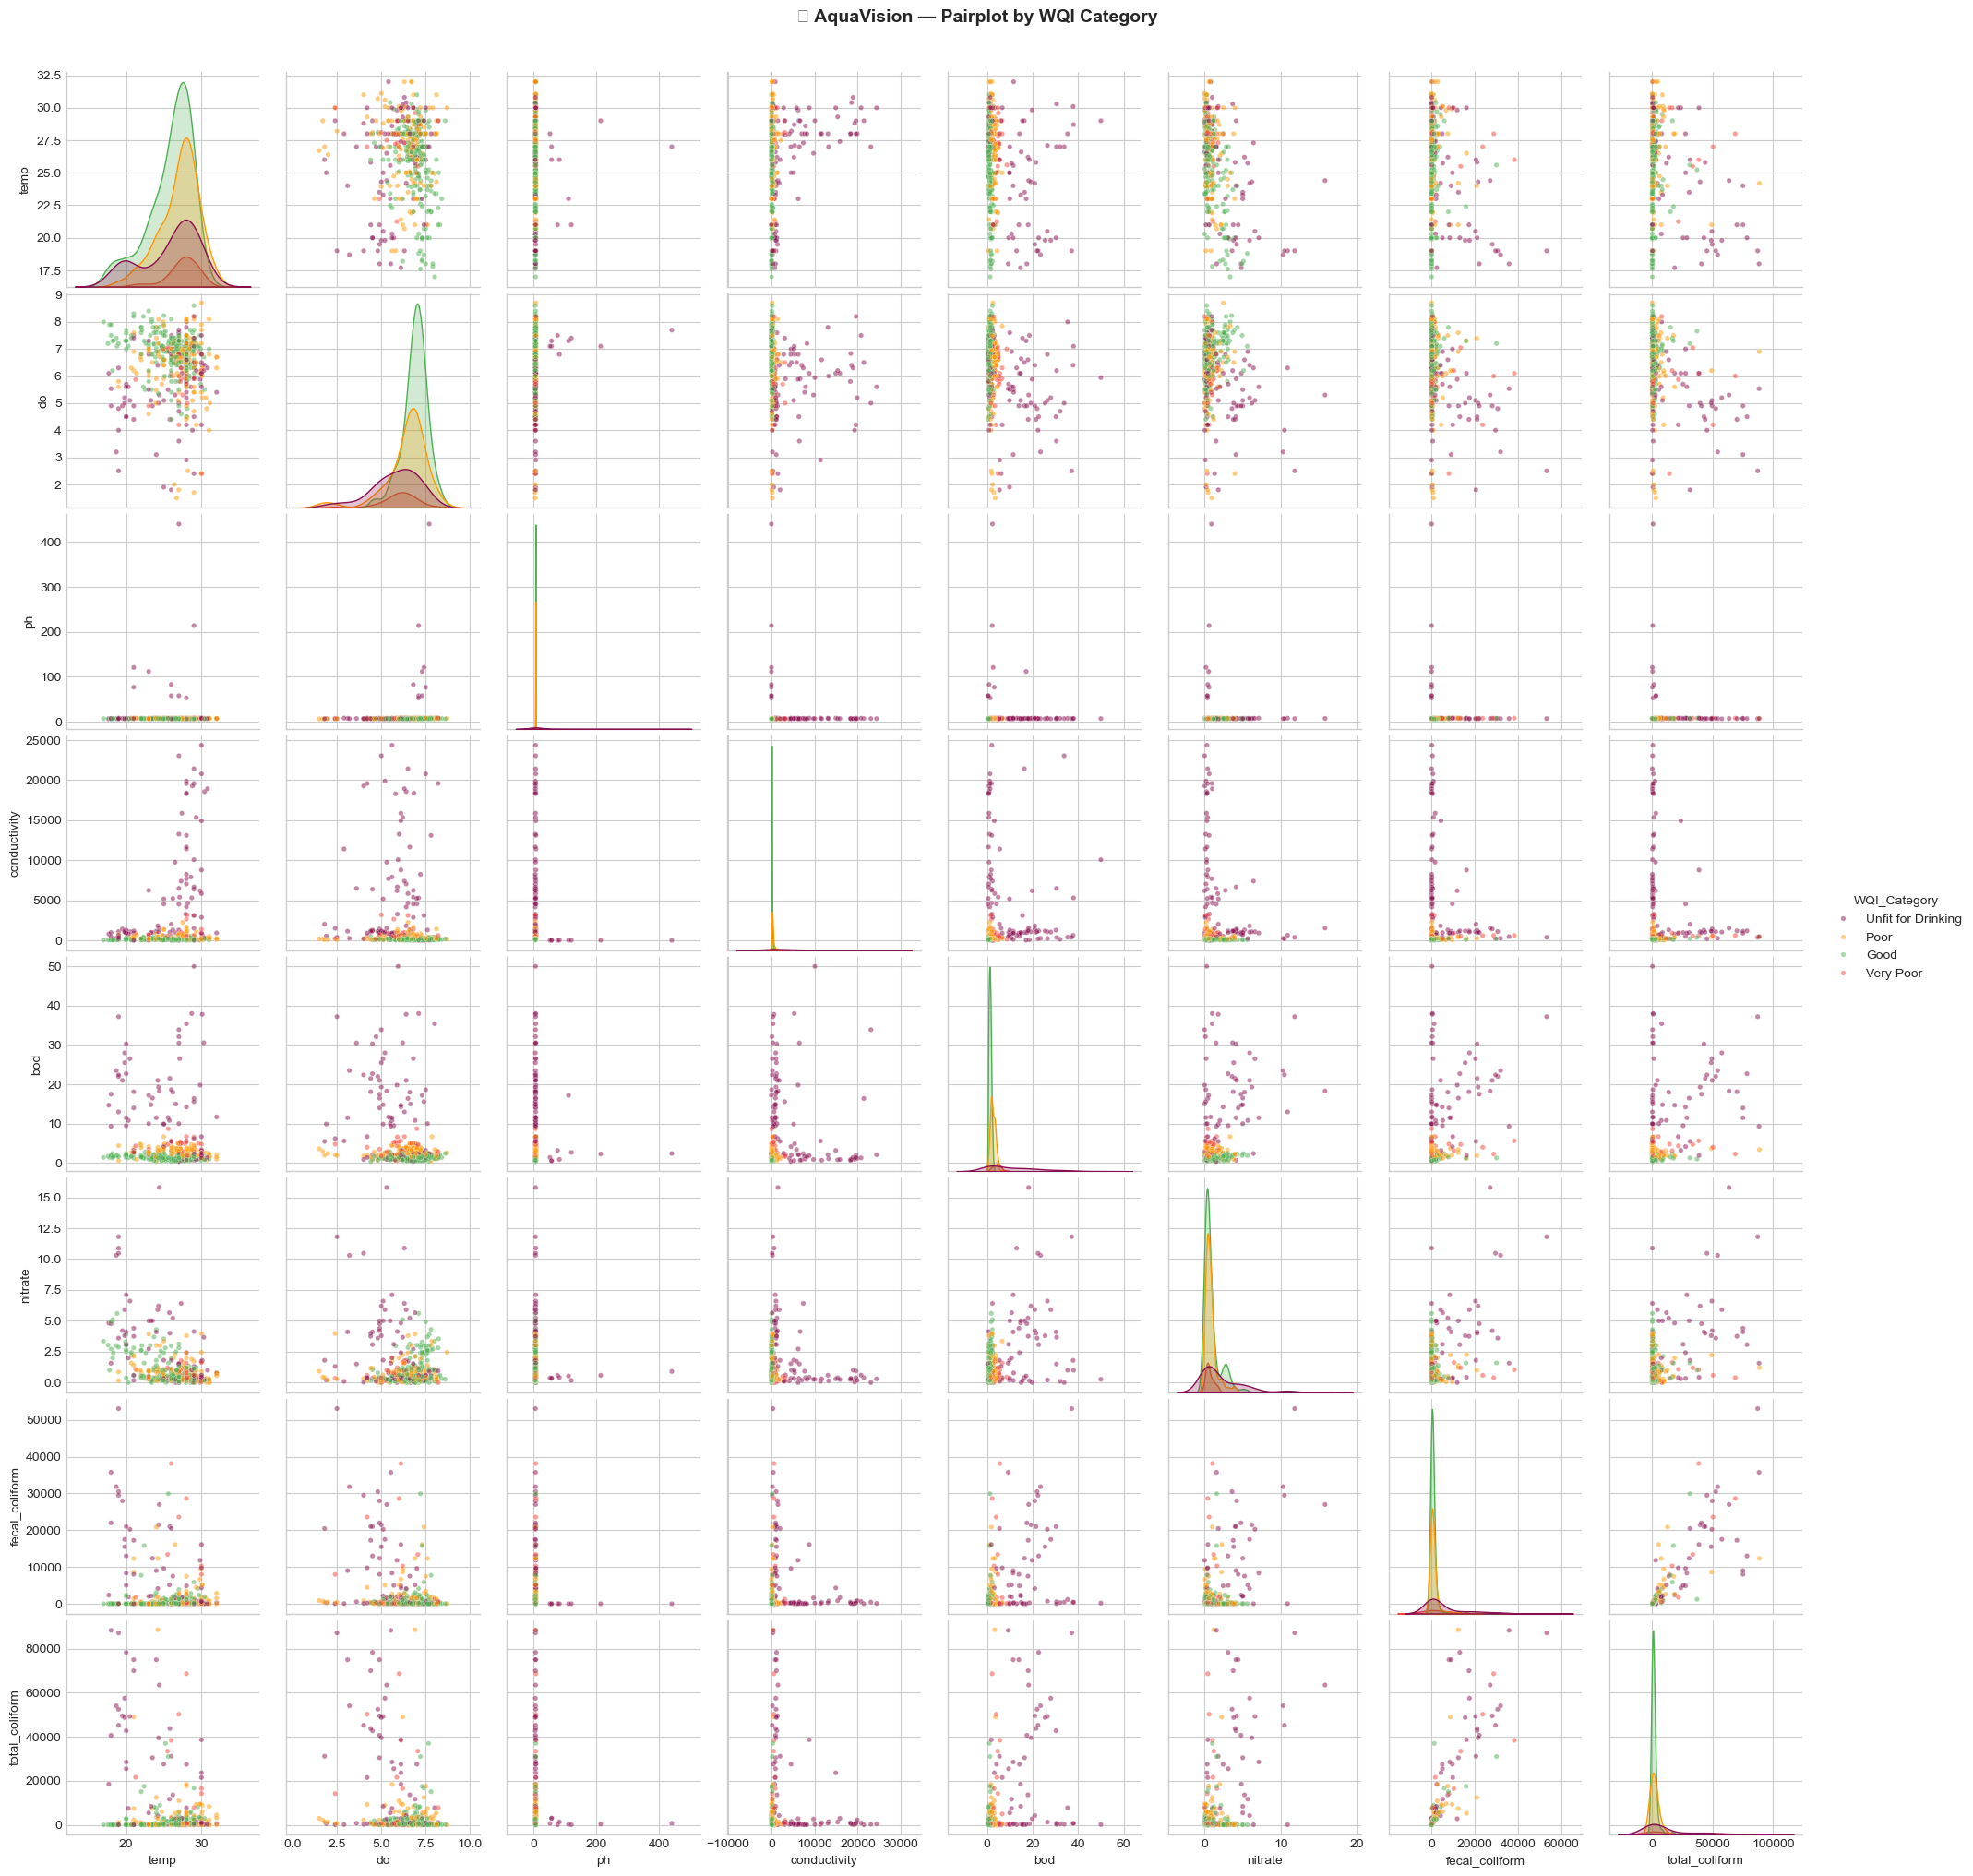

In [17]:
# Sample for pairplot (faster)
sample = df_clean[num_cols + ['WQI_Category']].sample(min(500, len(df_clean)), random_state=42)
g = sns.pairplot(sample, hue='WQI_Category',
                 palette={'Excellent':'#1B5E20','Good':'#4CAF50','Poor':'#FF9800',
                           'Very Poor':'#F44336','Unfit for Drinking':'#880E4F'},
                 plot_kws={'alpha': 0.5, 's': 15}, diag_kind='kde')
g.fig.suptitle('💧 AquaVision — Pairplot by WQI Category', y=1.02, fontsize=14, fontweight='bold')
plt.show()

In [18]:
# PCA Visualization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean[num_cols])

pca = PCA(n_components=2)
pca_coords = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({'PC1': pca_coords[:,0], 'PC2': pca_coords[:,1],
                       'Category': df_clean['WQI_Category'].values})

fig = px.scatter(pca_df, x='PC1', y='PC2', color='Category',
                 title='💧 AquaVision — PCA (2D Projection by WQI Category)',
                 color_discrete_map={
                     'Excellent':'#1B5E20','Good':'#4CAF50','Poor':'#FF9800',
                     'Very Poor':'#F44336','Unfit for Drinking':'#880E4F'
                 },
                 opacity=0.65, template='plotly_white',
                 labels={'PC1': f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)',
                         'PC2': f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)'})
fig.show()

---
## 🤖 WEEK 2 — Machine Learning: WQI Prediction

### Feature Engineering

In [20]:
df_ml = df_clean.copy()

# Feature engineering
df_ml['do_ph_ratio']       = df_ml['do'] / (df_ml['ph'] + 1e-6)
df_ml['bod_do_ratio']      = df_ml['bod'] / (df_ml['do'] + 1e-6)
df_ml['coliform_log']      = np.log1p(df_ml['total_coliform'])
df_ml['fecal_log']         = np.log1p(df_ml['fecal_coliform'])
df_ml['ph_deviation']      = (df_ml['ph'] - 7.0).abs()  # deviation from ideal pH
df_ml['do_deficit']        = (14.6 - df_ml['do']).clip(lower=0)  # oxygen deficit
df_ml['conductivity_log']  = np.log1p(df_ml['conductivity'])

FEATURES = [
    'temp', 'do', 'ph', 'conductivity', 'bod', 'nitrate',
    'fecal_coliform', 'total_coliform',
    'do_ph_ratio', 'bod_do_ratio', 'coliform_log', 'fecal_log',
    'ph_deviation', 'do_deficit', 'conductivity_log'
]

X = df_ml[FEATURES]
y = df_ml['WQI']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler_ml = StandardScaler()
X_train_s = scaler_ml.fit_transform(X_train)
X_test_s  = scaler_ml.transform(X_test)

print(f'Training samples : {X_train.shape[0]:,}')
print(f'Testing  samples : {X_test.shape[0]:,}')
print(f'Features         : {len(FEATURES)}')

Training samples : 1,384
Testing  samples : 347
Features         : 15


### Train Multiple Models & Compare

In [21]:
models = {
    'Linear Regression'         : LinearRegression(),
    'Ridge Regression'          : Ridge(alpha=1.0),
    'Decision Tree'             : DecisionTreeRegressor(max_depth=8, random_state=42),
    'Random Forest'             : RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting'         : GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost'                   : xgb.XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
    'LightGBM'                  : lgb.LGBMRegressor(n_estimators=100, random_state=42, verbosity=-1),
}

results = {}
for name, model in models.items():
    model.fit(X_train_s, y_train)
    preds = model.predict(X_test_s)
    results[name] = {
        'R2'   : round(r2_score(y_test, preds), 4),
        'RMSE' : round(np.sqrt(mean_squared_error(y_test, preds)), 4),
        'MAE'  : round(mean_absolute_error(y_test, preds), 4),
        'preds': preds
    }
    print(f'  {name:<28} R²={results[name]["R2"]:.4f}  RMSE={results[name]["RMSE"]:.4f}  MAE={results[name]["MAE"]:.4f}')

results_df = pd.DataFrame({k: {m: v for m, v in v.items() if m != 'preds'}
                            for k, v in results.items()}).T.sort_values('R2', ascending=False)
print('\n📊 Model Leaderboard:')
print(results_df)

  Linear Regression            R²=0.9998  RMSE=1.6839  MAE=1.3545
  Ridge Regression             R²=0.9998  RMSE=1.7106  MAE=1.3771
  Decision Tree                R²=0.9129  RMSE=33.3803  MAE=11.3469
  Random Forest                R²=0.9715  RMSE=19.0826  MAE=5.1707
  Gradient Boosting            R²=0.9907  RMSE=10.8927  MAE=4.2801
  XGBoost                      R²=0.9633  RMSE=21.6769  MAE=4.6322
  LightGBM                     R²=0.7825  RMSE=52.7513  MAE=15.9615

📊 Model Leaderboard:
                       R2     RMSE      MAE
Linear Regression  0.9998   1.6839   1.3545
Ridge Regression   0.9998   1.7106   1.3771
Gradient Boosting  0.9907  10.8927   4.2801
Random Forest      0.9715  19.0826   5.1707
XGBoost            0.9633  21.6769   4.6322
Decision Tree      0.9129  33.3803  11.3469
LightGBM           0.7825  52.7513  15.9615


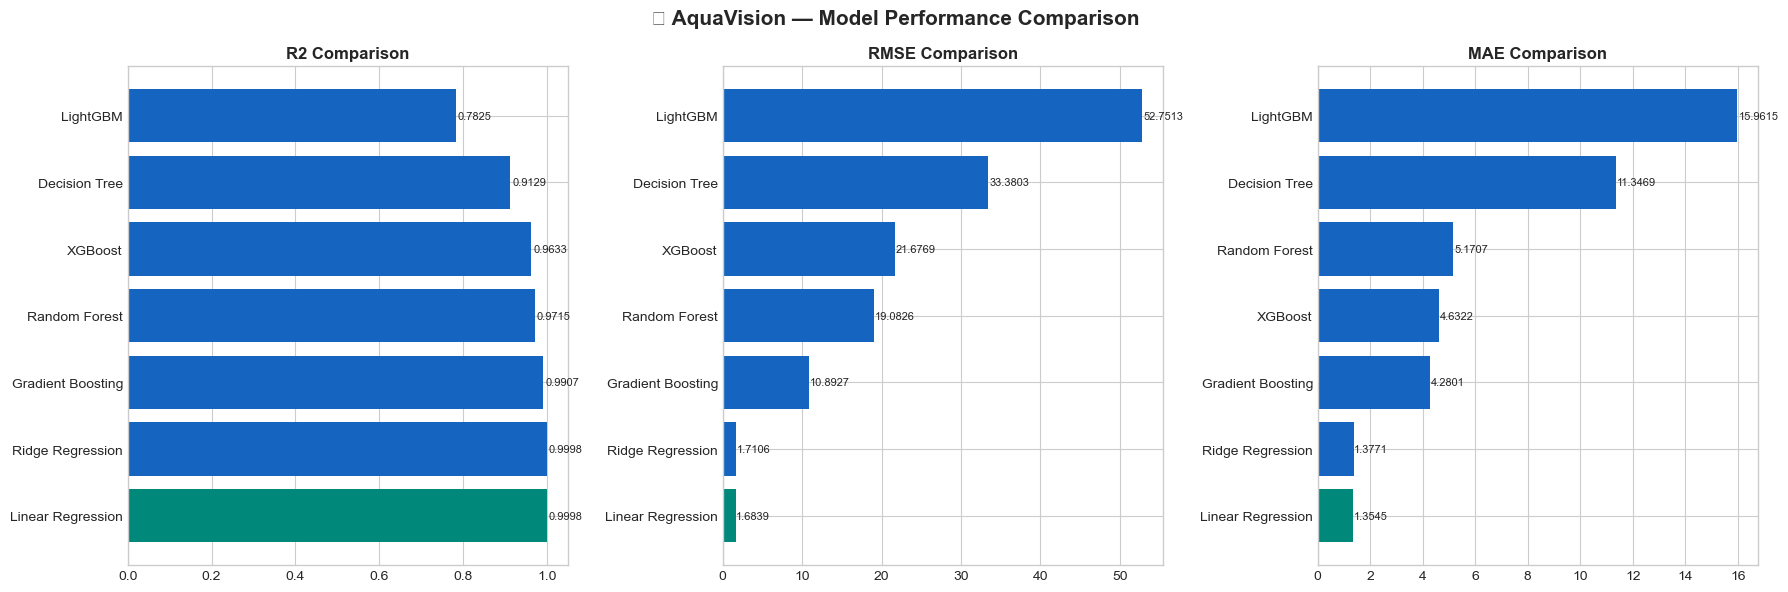

In [22]:
# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metrics = ['R2', 'RMSE', 'MAE']
for ax, metric in zip(axes, metrics):
    vals = results_df[metric].astype(float)
    ascending = metric != 'R2'
    vals_sorted = vals.sort_values(ascending=ascending)
    bar_colors = [TEAL if i == 0 else BLUE for i in range(len(vals_sorted))]
    ax.barh(vals_sorted.index, vals_sorted.values, color=bar_colors)
    ax.set_title(f'{metric} Comparison', fontsize=12, fontweight='bold')
    for i, v in enumerate(vals_sorted.values):
        ax.text(v * 1.005, i, f'{v:.4f}', va='center', fontsize=8)

plt.suptitle('💧 AquaVision — Model Performance Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### Best Model: XGBoost — Detailed Analysis

In [23]:
# Use XGBoost as best model (tune it)
best_model = xgb.XGBRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, verbosity=0
)
best_model.fit(X_train_s, y_train,
               eval_set=[(X_test_s, y_test)],
               verbose=False)

y_pred = best_model.predict(X_test_s)

print('='*50)
print('  🏆 Best Model: XGBoost (Tuned)')
print('='*50)
print(f'  R²   Score : {r2_score(y_test, y_pred):.4f}')
print(f'  RMSE       : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}')
print(f'  MAE        : {mean_absolute_error(y_test, y_pred):.4f}')
print('='*50)

  🏆 Best Model: XGBoost (Tuned)
  R²   Score : 0.9658
  RMSE       : 20.9210
  MAE        : 4.2686


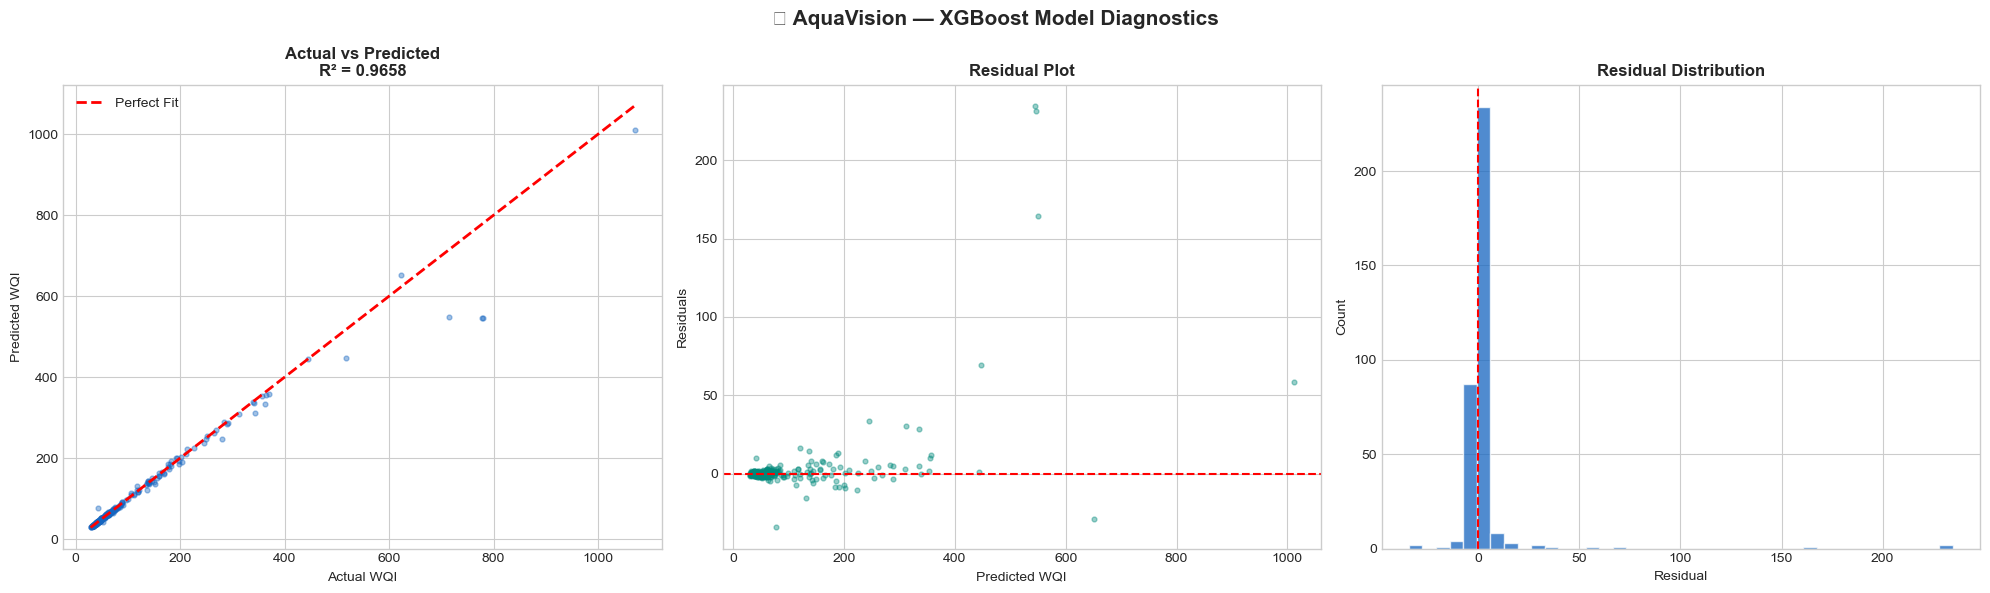

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.4, color=BLUE, s=12)
mn, mx = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
axes[0].plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Perfect Fit')
axes[0].set_xlabel('Actual WQI'); axes[0].set_ylabel('Predicted WQI')
axes[0].set_title(f'Actual vs Predicted\nR² = {r2_score(y_test, y_pred):.4f}', fontweight='bold')
axes[0].legend()

# Residuals
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.4, color=TEAL, s=12)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Predicted WQI'); axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot', fontweight='bold')

# Residual distribution
axes[2].hist(residuals, bins=40, color=BLUE, alpha=0.75, edgecolor='white')
axes[2].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[2].set_xlabel('Residual'); axes[2].set_ylabel('Count')
axes[2].set_title('Residual Distribution', fontweight='bold')

plt.suptitle('💧 AquaVision — XGBoost Model Diagnostics', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### Feature Importance & SHAP Analysis

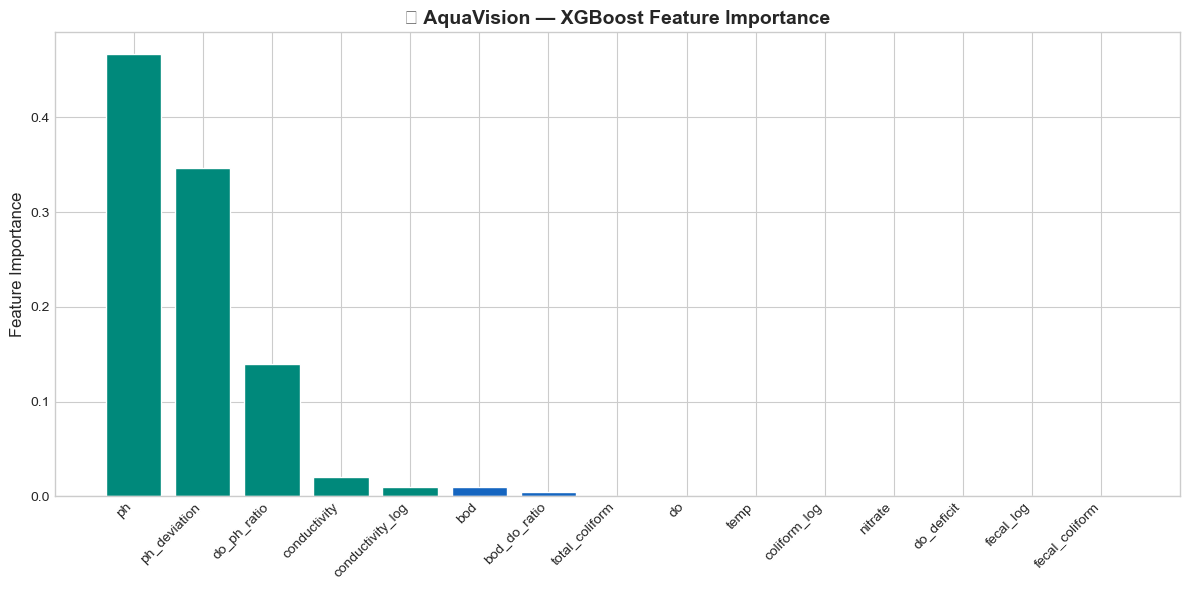

In [25]:
# Feature importance
fi = pd.Series(best_model.feature_importances_, index=FEATURES).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
colors = [TEAL if i < 5 else BLUE for i in range(len(fi))]
plt.bar(fi.index, fi.values, color=colors, edgecolor='white')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.ylabel('Feature Importance', fontsize=12)
plt.title('💧 AquaVision — XGBoost Feature Importance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

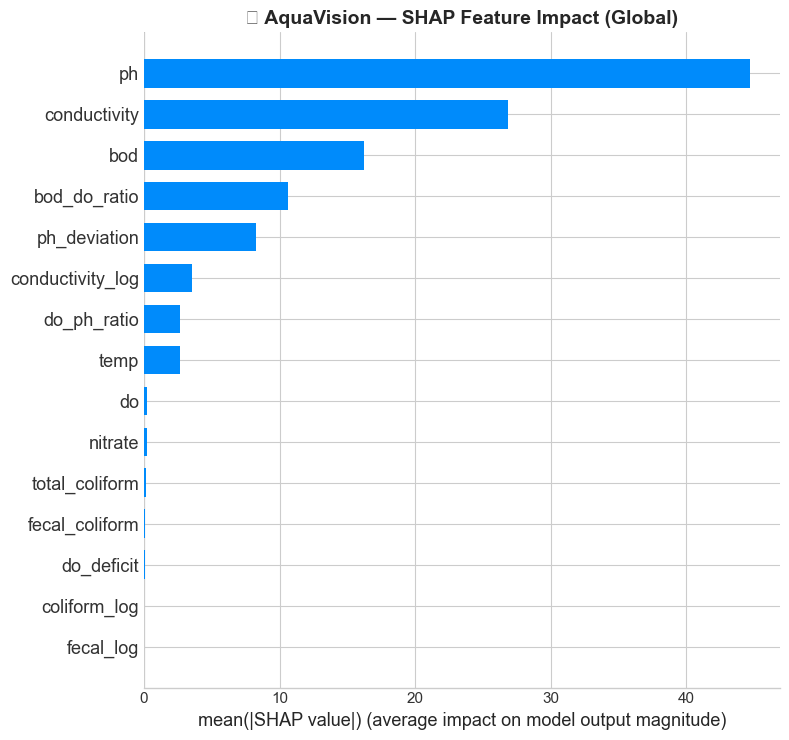

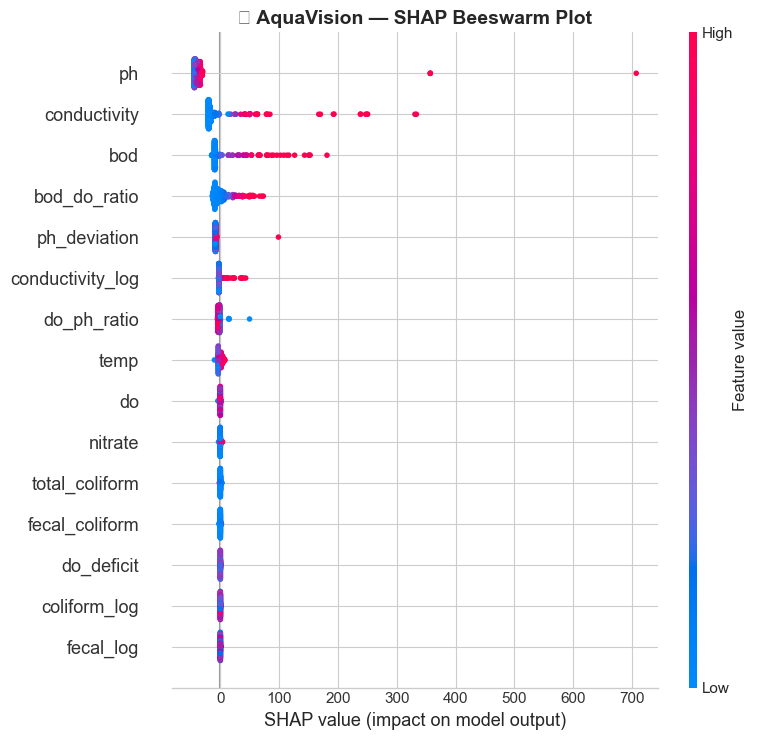

In [26]:
# SHAP explainability
explainer = shap.Explainer(best_model)
shap_values = explainer(pd.DataFrame(X_test_s, columns=FEATURES))

plt.figure(figsize=(12, 7))
shap.summary_plot(shap_values, pd.DataFrame(X_test_s, columns=FEATURES),
                  plot_type='bar', show=False)
plt.title('💧 AquaVision — SHAP Feature Impact (Global)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 7))
shap.summary_plot(shap_values, pd.DataFrame(X_test_s, columns=FEATURES), show=False)
plt.title('💧 AquaVision — SHAP Beeswarm Plot', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🏷️ WQI Classification Model

In [27]:
le = LabelEncoder()
y_cat = le.fit_transform(df_ml['WQI_Category'])

X_tr, X_te, y_tr, y_te = train_test_split(X, y_cat, test_size=0.2, random_state=42)
X_tr_s = scaler_ml.fit_transform(X_tr)
X_te_s = scaler_ml.transform(X_te)

clf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
clf.fit(X_tr_s, y_tr)
y_hat = clf.predict(X_te_s)

print(f'Classification Accuracy: {accuracy_score(y_te, y_hat)*100:.2f}%')
print()
print(classification_report(y_te, y_hat, target_names=le.classes_))

Classification Accuracy: 94.52%

                    precision    recall  f1-score   support

              Good       0.97      0.94      0.95       155
              Poor       0.88      0.94      0.91       105
Unfit for Drinking       1.00      1.00      1.00        69
         Very Poor       0.93      0.78      0.85        18

          accuracy                           0.95       347
         macro avg       0.95      0.92      0.93       347
      weighted avg       0.95      0.95      0.95       347



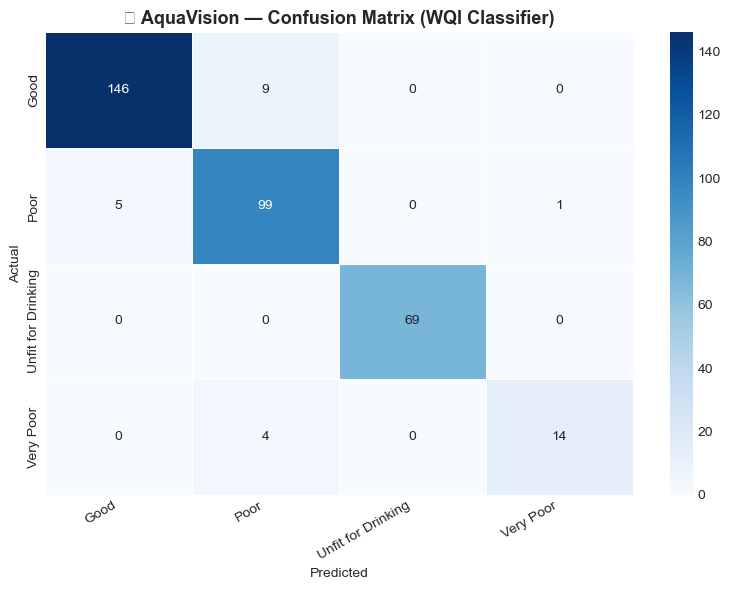

In [28]:
# Confusion Matrix
cm = confusion_matrix(y_te, y_hat)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=0.5)
plt.title('💧 AquaVision — Confusion Matrix (WQI Classifier)', fontsize=13, fontweight='bold')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

---
## 📈 Statistical Tests & Trend Analysis

In [29]:
# Normality tests
print('📐 Normality Tests (Shapiro-Wilk on 500-sample):')
sample_test = df_clean[num_cols].sample(500, random_state=42)
for col in num_cols:
    stat, p = shapiro(sample_test[col].dropna())
    normal = '✅ Normal' if p > 0.05 else '❌ Not Normal'
    print(f'  {col:<25} p={p:.4f}  {normal}')

📐 Normality Tests (Shapiro-Wilk on 500-sample):
  temp                      p=0.0000  ❌ Not Normal
  do                        p=0.0000  ❌ Not Normal
  ph                        p=0.0000  ❌ Not Normal
  conductivity              p=0.0000  ❌ Not Normal
  bod                       p=0.0000  ❌ Not Normal
  nitrate                   p=0.0000  ❌ Not Normal
  fecal_coliform            p=0.0000  ❌ Not Normal
  total_coliform            p=0.0000  ❌ Not Normal


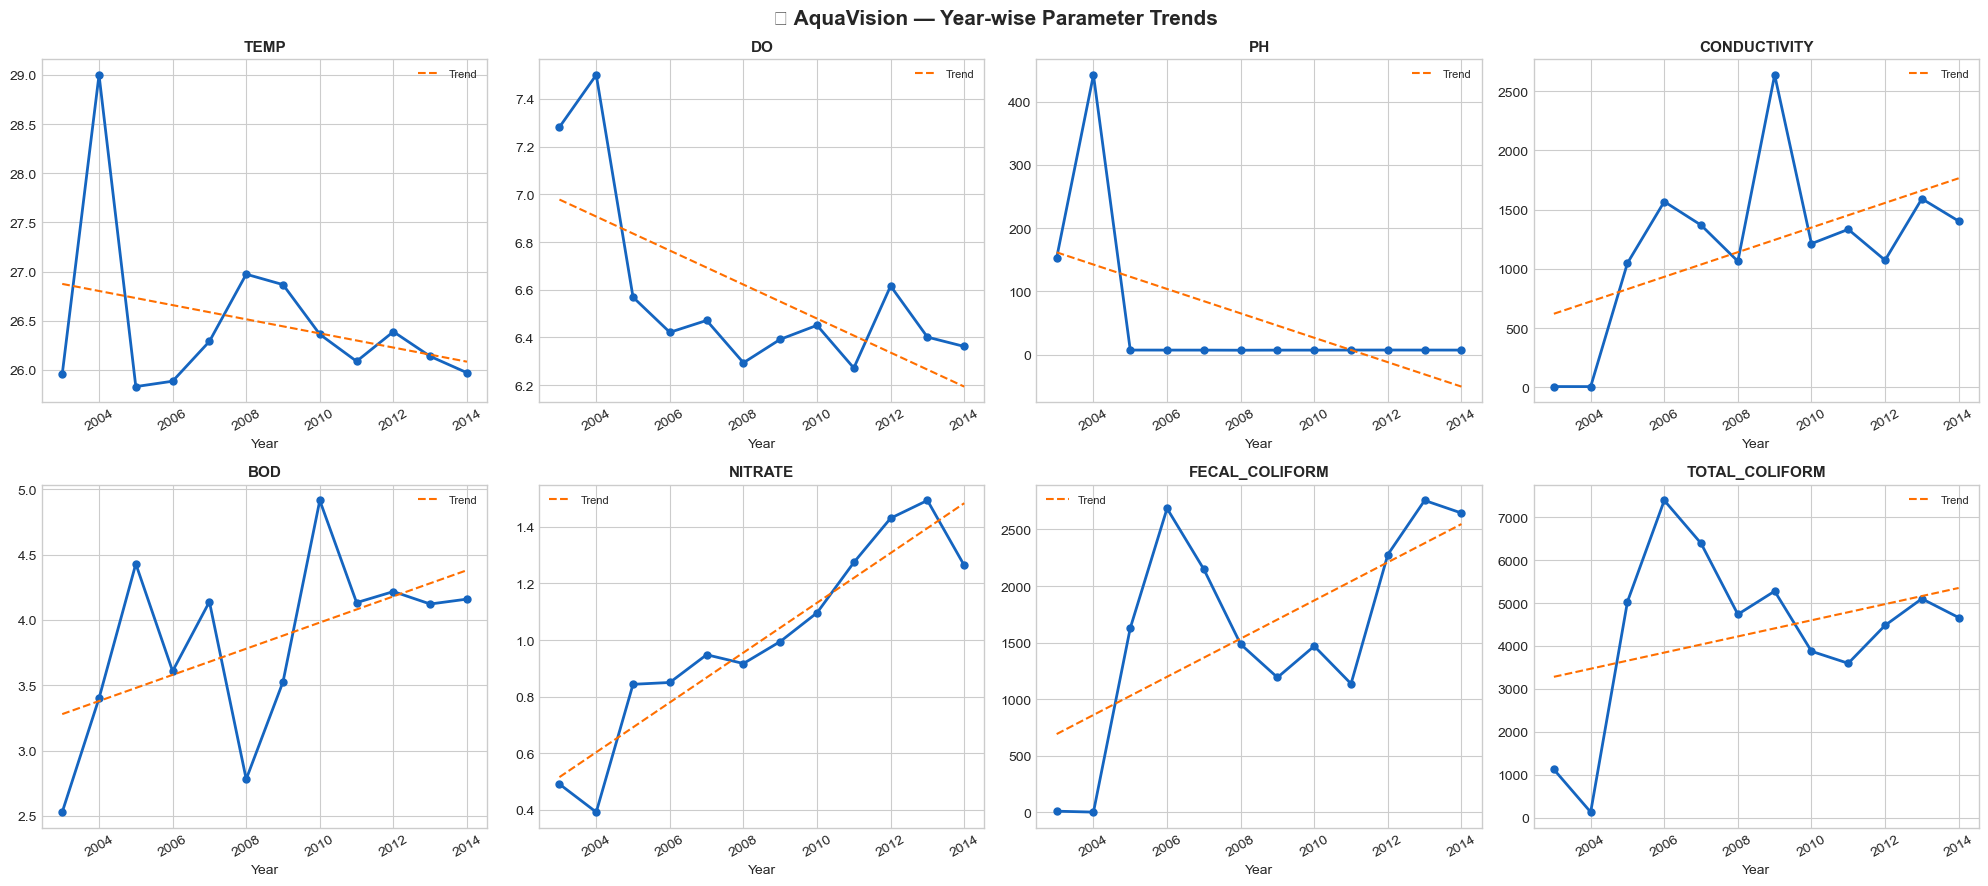

In [30]:
# Year-wise trend for each parameter
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    yr = df_clean.groupby('year')[col].mean()
    axes[i].plot(yr.index, yr.values, '-o', color=BLUE, linewidth=2, markersize=5)
    # Trend line
    z = np.polyfit(yr.index, yr.values, 1)
    p = np.poly1d(z)
    axes[i].plot(yr.index, p(yr.index), '--', color=WARN, linewidth=1.5, label=f'Trend')
    axes[i].set_title(col.upper(), fontsize=11, fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel('Year'); axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('💧 AquaVision — Year-wise Parameter Trends', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 💾 Save Models & Data for Streamlit

In [31]:
os.makedirs('aquavision_assets', exist_ok=True)

joblib.dump(best_model,  'aquavision_assets/wqi_regressor.pkl')
joblib.dump(clf,         'aquavision_assets/wqi_classifier.pkl')
joblib.dump(scaler_ml,   'aquavision_assets/scaler.pkl')
joblib.dump(le,          'aquavision_assets/label_encoder.pkl')
joblib.dump(FEATURES,    'aquavision_assets/feature_names.pkl')

df_clean.to_csv('aquavision_assets/clean_data.csv', index=False)

print('✅ All models and data saved to aquavision_assets/')
print('\nFiles saved:')
for f in os.listdir('aquavision_assets'):
    size = os.path.getsize(f'aquavision_assets/{f}') / 1024
    print(f'  {f:<35} {size:.1f} KB')

✅ All models and data saved to aquavision_assets/

Files saved:
  clean_data.csv                      188.9 KB
  feature_names.pkl                   0.2 KB
  label_encoder.pkl                   0.5 KB
  scaler.pkl                          1.4 KB
  wqi_classifier.pkl                  3917.0 KB
  wqi_regressor.pkl                   553.4 KB


---
## ✅ Summary

| Step | Status |
|------|--------|
| Data Loading & EDA | ✅ Complete |
| Missing Value Handling (KNN) | ✅ Complete |
| WQI Calculation (CPCB Method) | ✅ Complete |
| Outlier Detection & Removal | ✅ Complete |
| Feature Engineering | ✅ Complete |
| Correlation & PCA Analysis | ✅ Complete |
| Model Training (7 models) | ✅ Complete |
| Best Model: XGBoost | ✅ Complete |
| SHAP Explainability | ✅ Complete |
| WQI Classification | ✅ Complete |
| Statistical Tests | ✅ Complete |
| Models Saved for Streamlit | ✅ Complete |

> **Next Step → Run `streamlit run aquavision_app.py`**